<a href="https://colab.research.google.com/github/ixau0-0/final-project/blob/main/02_features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder

هنا حملنا البيانات وعرضناها

In [ ]:
data= pd.read_csv("cleaned_data.csv")
data

,age,sex,bmi,children,smoker,region,charges,age_capped,bmi_capped,children_capped,charges_capped
0,19,female,27.900,0,yes,southwest,16884.92400,19,27.900,0,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230,18,33.770,1,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200,28,33.000,3,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061,33,22.705,0,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520,32,28.880,0,3866.85520
...,...,...,...,...,...,...,...,...,...,...,...
1332,50,male,30.970,3,no,northwest,10600.54830,50,30.970,3,10600.54830
1333,18,female,31.920,0,no,northeast,2205.98080,18,31.920,0,2205.98080
1334,18,female,36.850,0,no,southeast,1629.83350,18,36.850,0,1629.83350
1335,21,female,25.800,0,no,southwest,2007.94500,21,25.800,0,2007.94500


 هاذي الخطوه تسمى ون هوت انكودينج نحول الفئات الى ارقام عشان يفهمها الجهاز

In [ ]:
cat=data[["region", "smoker",'sex']]
one_hot= pd.get_dummies(cat, columns=["region", "smoker",'sex'],drop_first=True).astype(int)
print(one_hot)

      region_northwest  region_southeast  region_southwest  smoker_yes  \
0                    0                 0                 1           1   
1                    0                 1                 0           0   
2                    0                 1                 0           0   
3                    1                 0                 0           0   
4                    1                 0                 0           0   
...                ...               ...               ...         ...   
1332                 1                 0                 0           0   
1333                 0                 0                 0           0   
1334                 0                 1                 0           0   
1335                 0                 0                 1           0   
1336                 1                 0                 0           1   

      sex_male  
0            0  
1            1  
2            1  
3            1  
4            1  
...      

استخدمنا ( StandardScaler)للاعمدة الرقمية عشان تكون في نفس المقياس

In [ ]:
num=data[["age",'bmi',"children"]]
scaler= StandardScaler()
scaled_data= scaler.fit_transform(num)
scaled_df= pd.DataFrame(scaled_data, columns=num.columns)
scaled_df

,age,bmi,children
0,-1.440418,-0.453160,-0.909234
1,-1.511647,0.509422,-0.079442
2,-0.799350,0.383155,1.580143
3,-0.443201,-1.305052,-0.909234
4,-0.514431,-0.292456,-0.909234
...,...,...,...
1332,0.767704,0.050269,1.580143
1333,-1.511647,0.206053,-0.909234
1334,-1.511647,1.014490,-0.909234
1335,-1.297958,-0.797524,-0.909234


هنا سوينا اعمده جديده لزيادة فهم العلاقات

In [ ]:
data["charges_per_child"] = data["charges"] / data["children"].replace(0, np.nan)

data["bmi_per_age"] = data["bmi"] / data["age"].replace(0, np.nan)

data["charges_per_bmi"] = data["charges"] / data["bmi"].replace(0, np.nan)

هنا نضرب عامودين عشان نشوف اذا في بينهم علاقة خطية او لا واذا ب ساعدني بعدين بتنبؤ

In [ ]:
data["smoker_numeric"] = data["smoker"].map({"yes": 1, "no": 0})
#الجهاز يفهم الأرقام مايفهم النصوص فهذي طريقة يسوي فيها الموديل الحسابات
data["smoker_bmi"] = data["smoker_numeric"] * data["bmi"]

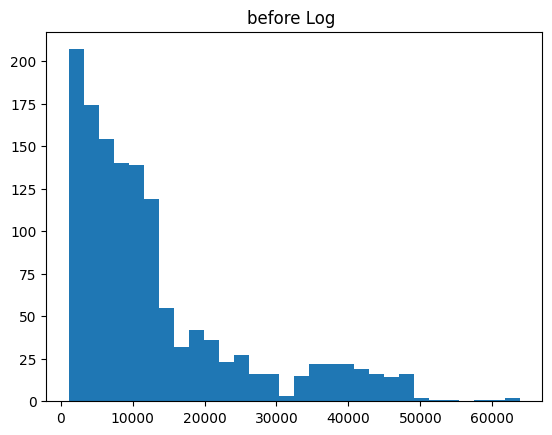

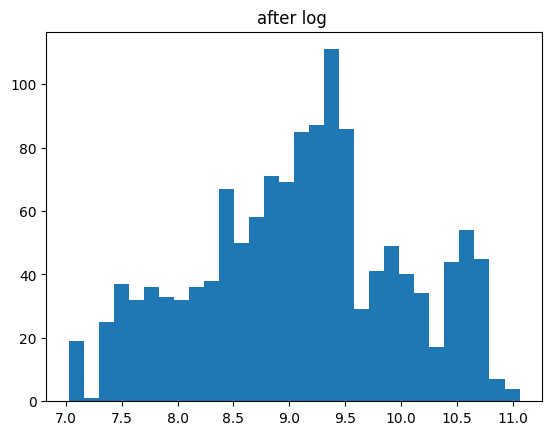

In [ ]:
plt.hist(data["charges"], bins=30)
plt.title("before Log ")
plt.show()

data["charges_log"] = np.log1p(data["charges"])

plt.hist(data["charges_log"], bins=30)
plt.title("after log ")
plt.show()
# يقلل تأثير الناس اللي تكاليفهم عالية جدًا عشان الموديل ما يتلخبط

In [ ]:
bins = [0, 18, 40, 100]
labels = ["young", "adult", "old"]
data["age_group"] = pd.cut(data["age"], bins=bins, labels=labels)
print(data[["age", "age_group"]].head(10))

   age age_group
0   19     adult
1   18     young
2   28     adult
3   33     adult
4   32     adult
5   31     adult
6   46       old
7   37     adult
8   37     adult
9   60       old


In [ ]:
encoder = OrdinalEncoder(categories=[["young", "adult", "old"]])
data ["age_group_encoded"]  = encoder.fit_transform(data[["age_group"]])
print(data[["age_group", "age_group_encoded"]])
#قسمنا الأعمار إلى مجموعات وحطينا لها رموز بالارقام عشان يسهل على الجهاز فهمها

     age_group  age_group_encoded
0        adult                1.0
1        young                0.0
2        adult                1.0
3        adult                1.0
4        adult                1.0
...        ...                ...
1332       old                2.0
1333     young                0.0
1334     young                0.0
1335     adult                1.0
1336       old                2.0

[1337 rows x 2 columns]


In [ ]:
data

,age,sex,bmi,children,smoker,region,charges,age_capped,bmi_capped,children_capped,charges_capped,charges_per_child,bmi_per_age,charges_per_bmi,smoker_numeric,smoker_bmi,charges_log,age_group,age_group_encoded
0,19,female,27.900,0,yes,southwest,16884.92400,19,27.900,0,16884.92400,NaN,1.468421,605.194409,1,27.90,9.734236,adult,1.0
1,18,male,33.770,1,no,southeast,1725.55230,18,33.770,1,1725.55230,1725.5523,1.876111,51.097196,0,0.00,7.453882,young,0.0
2,28,male,33.000,3,no,southeast,4449.46200,28,33.000,3,4449.46200,1483.1540,1.178571,134.832182,0,0.00,8.400763,adult,1.0
3,33,male,22.705,0,no,northwest,21984.47061,33,22.705,0,21984.47061,NaN,0.688030,968.265607,0,0.00,9.998137,adult,1.0
4,32,male,28.880,0,no,northwest,3866.85520,32,28.880,0,3866.85520,NaN,0.902500,133.893878,0,0.00,8.260455,adult,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1332,50,male,30.970,3,no,northwest,10600.54830,50,30.970,3,10600.54830,3533.5161,0.619400,342.284414,0,0.00,9.268755,old,2.0
1333,18,female,31.920,0,no,northeast,2205.98080,18,31.920,0,2205.98080,NaN,1.773333,69.109674,0,0.00,7.699381,young,0.0
1334,18,female,36.850,0,no,southeast,1629.83350,18,36.850,0,1629.83350,NaN,2.047222,44.228860,0,0.00,7.396847,young,0.0
1335,21,female,25.800,0,no,southwest,2007.94500,21,25.800,0,2007.94500,NaN,1.228571,77.827326,0,0.00,7.605365,adult,1.0


In [ ]:
data = data.drop(columns=["charges_per_child", "charges_per_bmi"])
data = data.drop(columns=["smoker_bmi", "age_group"])

In [ ]:
data

,age,sex,bmi,children,smoker,region,charges,age_capped,bmi_capped,children_capped,charges_capped,bmi_per_age,smoker_numeric,charges_log,age_group_encoded
0,19,female,27.900,0,yes,southwest,16884.92400,19,27.900,0,16884.92400,1.468421,1,9.734236,1.0
1,18,male,33.770,1,no,southeast,1725.55230,18,33.770,1,1725.55230,1.876111,0,7.453882,0.0
2,28,male,33.000,3,no,southeast,4449.46200,28,33.000,3,4449.46200,1.178571,0,8.400763,1.0
3,33,male,22.705,0,no,northwest,21984.47061,33,22.705,0,21984.47061,0.688030,0,9.998137,1.0
4,32,male,28.880,0,no,northwest,3866.85520,32,28.880,0,3866.85520,0.902500,0,8.260455,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1332,50,male,30.970,3,no,northwest,10600.54830,50,30.970,3,10600.54830,0.619400,0,9.268755,2.0
1333,18,female,31.920,0,no,northeast,2205.98080,18,31.920,0,2205.98080,1.773333,0,7.699381,0.0
1334,18,female,36.850,0,no,southeast,1629.83350,18,36.850,0,1629.83350,2.047222,0,7.396847,0.0
1335,21,female,25.800,0,no,southwest,2007.94500,21,25.800,0,2007.94500,1.228571,0,7.605365,1.0


In [ ]:
corr_matrix = data.corr(numeric_only=True)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
data = data.drop(columns=to_drop)

In [ ]:
data

,age,sex,bmi,children,smoker,region,charges,bmi_per_age,smoker_numeric,charges_log,age_group_encoded
0,19,female,27.900,0,yes,southwest,16884.92400,1.468421,1,9.734236,1.0
1,18,male,33.770,1,no,southeast,1725.55230,1.876111,0,7.453882,0.0
2,28,male,33.000,3,no,southeast,4449.46200,1.178571,0,8.400763,1.0
3,33,male,22.705,0,no,northwest,21984.47061,0.688030,0,9.998137,1.0
4,32,male,28.880,0,no,northwest,3866.85520,0.902500,0,8.260455,1.0
...,...,...,...,...,...,...,...,...,...,...,...
1332,50,male,30.970,3,no,northwest,10600.54830,0.619400,0,9.268755,2.0
1333,18,female,31.920,0,no,northeast,2205.98080,1.773333,0,7.699381,0.0
1334,18,female,36.850,0,no,southeast,1629.83350,2.047222,0,7.396847,0.0
1335,21,female,25.800,0,no,southwest,2007.94500,1.228571,0,7.605365,1.0


In [ ]:
data.to_csv('features_data.csv', index=False)
from google.colab import files
files.download("features_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>